# Praktikum Teknik Peramalan
## Metode Holt's Double Exponential Smoothing

**Nama:** Ade Nafil Firmansah  
**NIM:** 3012210002  
**Dataset:** Monthly Airline Passengers (1949–1960)  
**Sumber:** CSV GitHub Jason Brownlee dengan fallback offline lokal (https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv)
**Metode:** Holt's Method (Double Exponential Smoothing)

---

### Latar Belakang
Dataset ini berisi jumlah penumpang maskapai penerbangan internasional setiap bulan dari Januari 1949 hingga Desember 1960 (144 periode). 

---
## Sel 1 — Import Library

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Coba import statsmodels (jika tersedia, dipakai untuk validasi)
try:
    from statsmodels.tsa.holtwinters import Holt
    STATSMODELS_AVAILABLE = True
    print("✅ statsmodels tersedia — akan digunakan sebagai validasi")
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("ℹ️  statsmodels tidak terinstall — menggunakan implementasi manual (hasil tetap valid)")

OUTPUT_DIR = Path.cwd() / 'output_plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")
print("Import selesai ✅")

✅ statsmodels tersedia — akan digunakan sebagai validasi
pandas  : 2.2.2
numpy   : 2.0.2
Output dir: /content/output_plots
Import selesai ✅


---
## Sel 2 — Load Data

In [ ]:
# ================================================================
# DATA AIRLINE PASSENGERS (144 observasi bulanan, 1949-1960)
# Sumber utama : CSV GitHub Jason Brownlee
# Fallback     : data offline yang di-embed di notebook
# ================================================================

DATA_URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

# Fallback offline agar notebook tetap jalan jika GitHub tidak bisa diakses karena dinuklir loh yah
raw_data = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432
]

dates = pd.date_range(start='1949-01', periods=144, freq='MS')
offline_df = pd.DataFrame({'date': dates, 'value': raw_data})

try:
    df = pd.read_csv(DATA_URL)
    df.columns = [col.strip().lower() for col in df.columns]
    df = df.rename(columns={'month': 'date', 'passengers': 'value'})
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'])
    data_source = f'GitHub CSV: {DATA_URL}'
except Exception as exc:
    print(f'⚠️ Gagal mengambil data dari GitHub ⚛️⚛️ duarr 🫡: {exc}')
    df = offline_df.copy()
    data_source = 'Fallback offline embedded dataset'

df.set_index('date', inplace=True)

print(f"Dataset berhasil dimuat!")
print(f"Sumber data       : {data_source}")
print(f"Jumlah observasi : {len(df)} periode")
print(f"Periode          : {df.index[0].strftime('%B %Y')} — {df.index[-1].strftime('%B %Y')}")
print(f"\n5 baris pertama:")
df.head()

Dataset berhasil dimuat!
Sumber data       : GitHub CSV: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
Jumlah observasi : 144 periode
Periode          : January 1949 — December 1960

5 baris pertama:


,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


---
## Sel 3 — Cleaning & Standardisasi

In [13]:
# Pastikan tipe data benar
df.index = pd.to_datetime(df.index)
df['value'] = pd.to_numeric(df['value'])

# Urutkan berdasarkan tanggal (ascending)
df.sort_index(inplace=True)
freq = pd.infer_freq(df.index)

print("Info DataFrame:")
print(df.info())
print(f"\nTipe index : {type(df.index)}")
print(f"Frekuensi  : {freq if freq else 'tidak terdeteksi'}")

Info DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None

Tipe index : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Frekuensi  : MS


---
## Sel 4 — Validasi Data

In [14]:
print("=" * 50)
print("VALIDASI DATA")
print("=" * 50)

# Cek 1: Jumlah observasi
n = len(df)
assert n >= 100, f"GAGAL: hanya {n} observasi, minimum 100"
print(f"✅ Jumlah observasi : {n} (>= 100)")

# Cek 2: Missing values
missing = df['value'].isna().sum()
assert missing == 0, f"GAGAL: ditemukan {missing} nilai kosong"
print(f"✅ Missing values   : {missing} (tidak ada)")

# Cek 3: Duplikasi bulan
duplicates = df.index.duplicated().sum()
assert duplicates == 0, f"GAGAL: ditemukan {duplicates} bulan duplikat"
print(f"✅ Bulan duplikat   : {duplicates} (tidak ada)")

# Cek 4: Index terurut naik
assert df.index.is_monotonic_increasing, "GAGAL: index tidak terurut naik"
print(f"✅ Urutan index     : ascending (benar)")

# Statistik deskriptif
print(f"\nStatistik Deskriptif:")
print(df['value'].describe().round(2))

VALIDASI DATA
✅ Jumlah observasi : 144 (>= 100)
✅ Missing values   : 0 (tidak ada)
✅ Bulan duplikat   : 0 (tidak ada)
✅ Urutan index     : ascending (benar)

Statistik Deskriptif:
count    144.00
mean     280.30
std      119.97
min      104.00
25%      180.00
50%      265.50
75%      360.50
max      622.00
Name: value, dtype: float64


---
## Sel 5 — Visualisasi Time Series

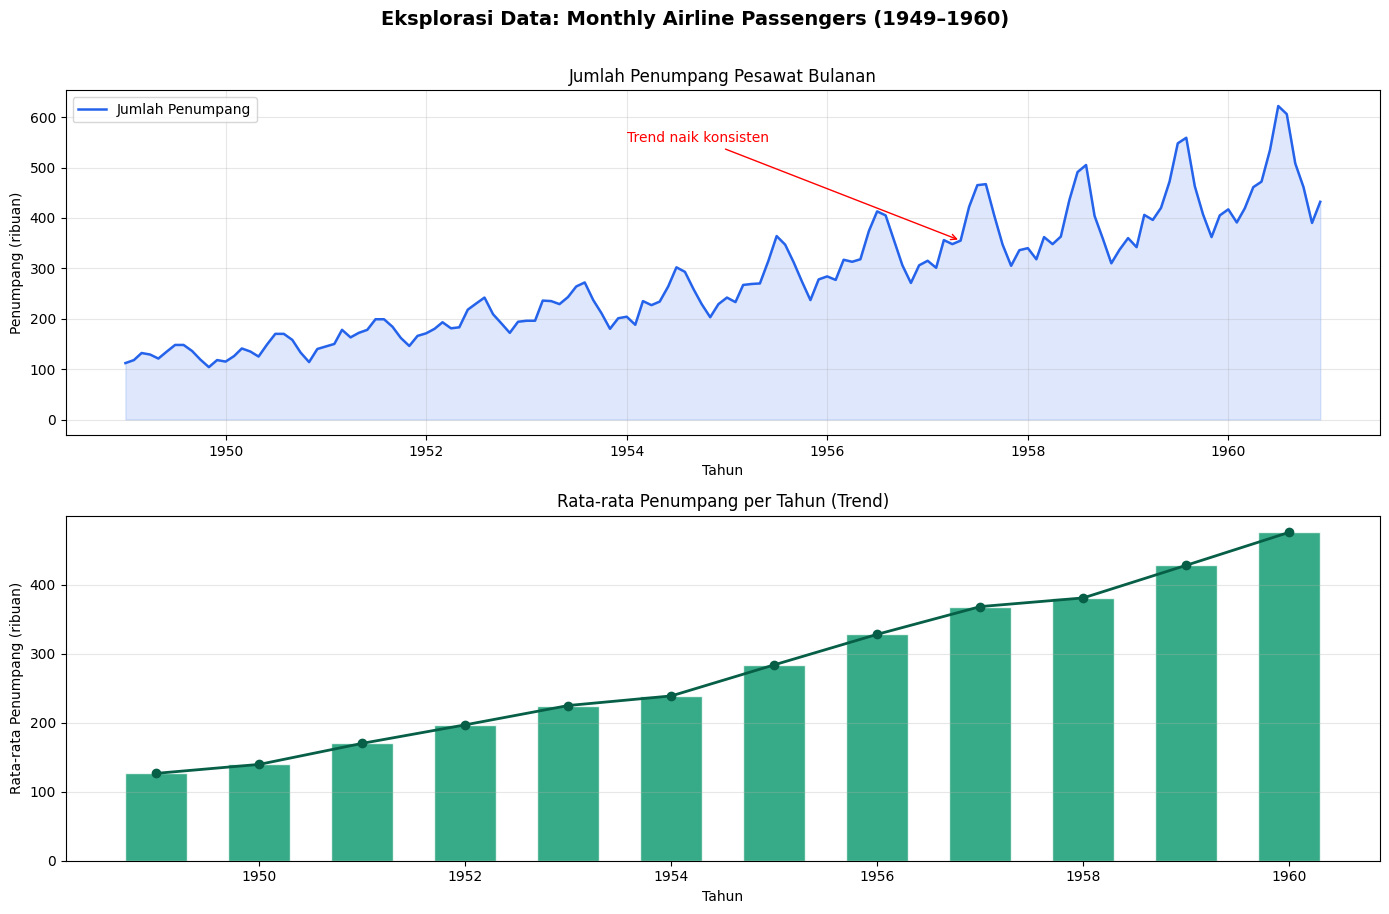

Plot eksplorasi disimpan di: /content/output_plots/plot_eksplorasi.png

📊 Identifikasi Pola:
• TREND     : Naik secara konsisten sepanjang 1949–1960
• MUSIMAN   : Ada pola fluktuasi tahunan (puncak musim panas, Juli–Agustus)
• IRREGULAR : Fluktuasi kecil/noise di sekitar pola utama
• KESIMPULAN: Metode Holt cocok karena data memiliki komponen TREND yang jelas


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Eksplorasi Data: Monthly Airline Passengers (1949–1960)',
             fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Time series lengkap ---
axes[0].plot(df.index, df['value'], color='#2563EB', linewidth=1.8, label='Jumlah Penumpang')
axes[0].fill_between(df.index, df['value'], alpha=0.15, color='#2563EB')
axes[0].set_title('Jumlah Penumpang Pesawat Bulanan', fontsize=12)
axes[0].set_ylabel('Penumpang (ribuan)')
axes[0].set_xlabel('Tahun')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Tambahkan anotasi trend
axes[0].annotate('Trend naik konsisten', xy=(df.index[100], df['value'].iloc[100]),
                 xytext=(df.index[60], 550),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# --- Plot 2: Rata-rata per tahun (untuk lihat trend lebih jelas) ---
df_yearly = df.resample('YE').mean()
axes[1].bar(df_yearly.index.year, df_yearly['value'],
            color='#059669', alpha=0.8, edgecolor='white', width=0.6)
axes[1].plot(df_yearly.index.year, df_yearly['value'],
             'o-', color='#065F46', linewidth=2, markersize=6)
axes[1].set_title('Rata-rata Penumpang per Tahun (Trend)', fontsize=12)
axes[1].set_ylabel('Rata-rata Penumpang (ribuan)')
axes[1].set_xlabel('Tahun')
axes[1].grid(True, alpha=0.3, axis='y')

plot_path = OUTPUT_DIR / 'plot_eksplorasi.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot eksplorasi disimpan di: {plot_path.resolve()}")

print("\n📊 Identifikasi Pola:")
print("• TREND     : Naik secara konsisten sepanjang 1949–1960")
print("• MUSIMAN   : Ada pola fluktuasi tahunan (puncak musim panas, Juli–Agustus)")
print("• IRREGULAR : Fluktuasi kecil/noise di sekitar pola utama")
print("• KESIMPULAN: Metode Holt cocok karena data memiliki komponen TREND yang jelas")

---
## Sel 6 — Train-Test Split

In [16]:
FORECAST_HORIZON = 15  # Forecast 15 periode ke depan

# Split: train = semua kecuali 15 terakhir, test = 15 terakhir
train = df.iloc[:-FORECAST_HORIZON]['value']
test  = df.iloc[-FORECAST_HORIZON:]['value']

print(f"Total data  : {len(df)} observasi")
print(f"Data train  : {len(train)} observasi ({train.index[0].strftime('%b %Y')} – {train.index[-1].strftime('%b %Y')})")
print(f"Data test   : {len(test)}  observasi ({test.index[0].strftime('%b %Y')} – {test.index[-1].strftime('%b %Y')})")
print(f"Horizon     : {FORECAST_HORIZON} periode ke depan")

# Validasi forecast horizon
assert len(test) == FORECAST_HORIZON, "ERROR: panjang test set tidak sesuai horizon"
print("\n✅ Split data valid")

Total data  : 144 observasi
Data train  : 129 observasi (Jan 1949 – Sep 1959)
Data test   : 15  observasi (Oct 1959 – Dec 1960)
Horizon     : 15 periode ke depan

✅ Split data valid


---
## Sel 7 — Fitting Model Holt

**Holt's Double Exponential Smoothing** terdiri dari dua persamaan:

$$l_t = \alpha \cdot y_t + (1 - \alpha)(l_{t-1} + b_{t-1})$$

$$b_t = \beta(l_t - l_{t-1}) + (1 - \beta) \cdot b_{t-1}$$

$$\hat{y}_{t+h} = l_t + h \cdot b_t$$

Di mana:
- $l_t$ = komponen **level** pada waktu $t$
- $b_t$ = komponen **trend** pada waktu $t$  
- $\alpha$ = parameter smoothing level $(0 < \alpha < 1)$
- $\beta$ = parameter smoothing trend $(0 < \beta < 1)$
- $h$ = langkah forecast ke depan

In [17]:
def holt_method(y, alpha, beta, h):
    """
    Implementasi Holt's Double Exponential Smoothing.

    Parameter:
        y     : array data time series (train)
        alpha : parameter smoothing level (0 < alpha < 1)
        beta  : parameter smoothing trend (0 < beta < 1)
        h     : jumlah periode forecast ke depan

    Return:
        fitted   : nilai fitted (in-sample)
        forecast : nilai forecast (out-of-sample)
        levels   : array komponen level
        trends   : array komponen trend
    """
    y = np.array(y, dtype=float)
    n = len(y)

    # Inisialisasi: level = nilai pertama, trend = rata-rata kenaikan awal
    l = np.zeros(n)
    b = np.zeros(n)
    l[0] = y[0]
    b[0] = y[1] - y[0] if n > 1 else 0.0

    # Update rekursif
    for t in range(1, n):
        l[t] = alpha * y[t] + (1 - alpha) * (l[t-1] + b[t-1])
        b[t] = beta  * (l[t] - l[t-1]) + (1 - beta) * b[t-1]

    # One-step-ahead fitted values, dimulai dari observasi ke-2
    fitted = np.full(n, np.nan)
    for t in range(1, n):
        fitted[t] = l[t-1] + b[t-1]

    # Forecast h langkah ke depan
    forecast = np.array([l[n-1] + (i+1) * b[n-1] for i in range(h)])

    return fitted, forecast, l, b


def optimize_holt(y, h_val=15, grid_size=20):
    """
    Cari alpha & beta optimal dengan grid search (minimasi SSE in-sample).
    """
    best_sse = np.inf
    best_alpha, best_beta = 0.1, 0.1

    alphas = np.linspace(0.05, 0.95, grid_size)
    betas  = np.linspace(0.05, 0.95, grid_size)

    for a in alphas:
        for b_val in betas:
            fitted, _, _, _ = holt_method(y, a, b_val, h_val)
            valid_idx = ~np.isnan(fitted)
            sse = np.sum((np.array(y)[valid_idx] - fitted[valid_idx]) ** 2)
            if sse < best_sse:
                best_sse   = sse
                best_alpha = a
                best_beta  = b_val

    return best_alpha, best_beta


# Optimasi parameter
print("🔍 Mencari parameter optimal (alpha, beta) via grid search...")
alpha_opt, beta_opt = optimize_holt(train.values, h_val=FORECAST_HORIZON)
print(f"   → alpha optimal : {alpha_opt:.4f}")
print(f"   → beta  optimal : {beta_opt:.4f}")

# Fit model dengan parameter optimal
fitted_vals, forecast_vals, levels, trends = holt_method(
    train.values, alpha_opt, beta_opt, FORECAST_HORIZON
)

# Buat index untuk forecast
forecast_index = pd.date_range(
    start=test.index[0], periods=FORECAST_HORIZON, freq='MS'
)
forecast_series = pd.Series(forecast_vals, index=forecast_index)

print(f"\n✅ Model Holt berhasil di-fit!")
print(f"\n📈 Nilai forecast 15 periode ke depan:")
print(pd.DataFrame({
    'Periode'  : forecast_index.strftime('%b %Y'),
    'Forecast' : forecast_vals.round(2),
    'Aktual'   : test.values
}).to_string(index=False))

🔍 Mencari parameter optimal (alpha, beta) via grid search...
   → alpha optimal : 0.9500
   → beta  optimal : 0.0500

✅ Model Holt berhasil di-fit!

📈 Nilai forecast 15 periode ke depan:
 Periode  Forecast  Aktual
Oct 1959    472.55     407
Nov 1959    476.84     362
Dec 1959    481.14     405
Jan 1960    485.43     417
Feb 1960    489.73     391
Mar 1960    494.03     419
Apr 1960    498.32     461
May 1960    502.62     472
Jun 1960    506.91     535
Jul 1960    511.21     622
Aug 1960    515.50     606
Sep 1960    519.80     508
Oct 1960    524.10     461
Nov 1960    528.39     390
Dec 1960    532.69     432


---
## Sel 8 — Visualisasi Forecast

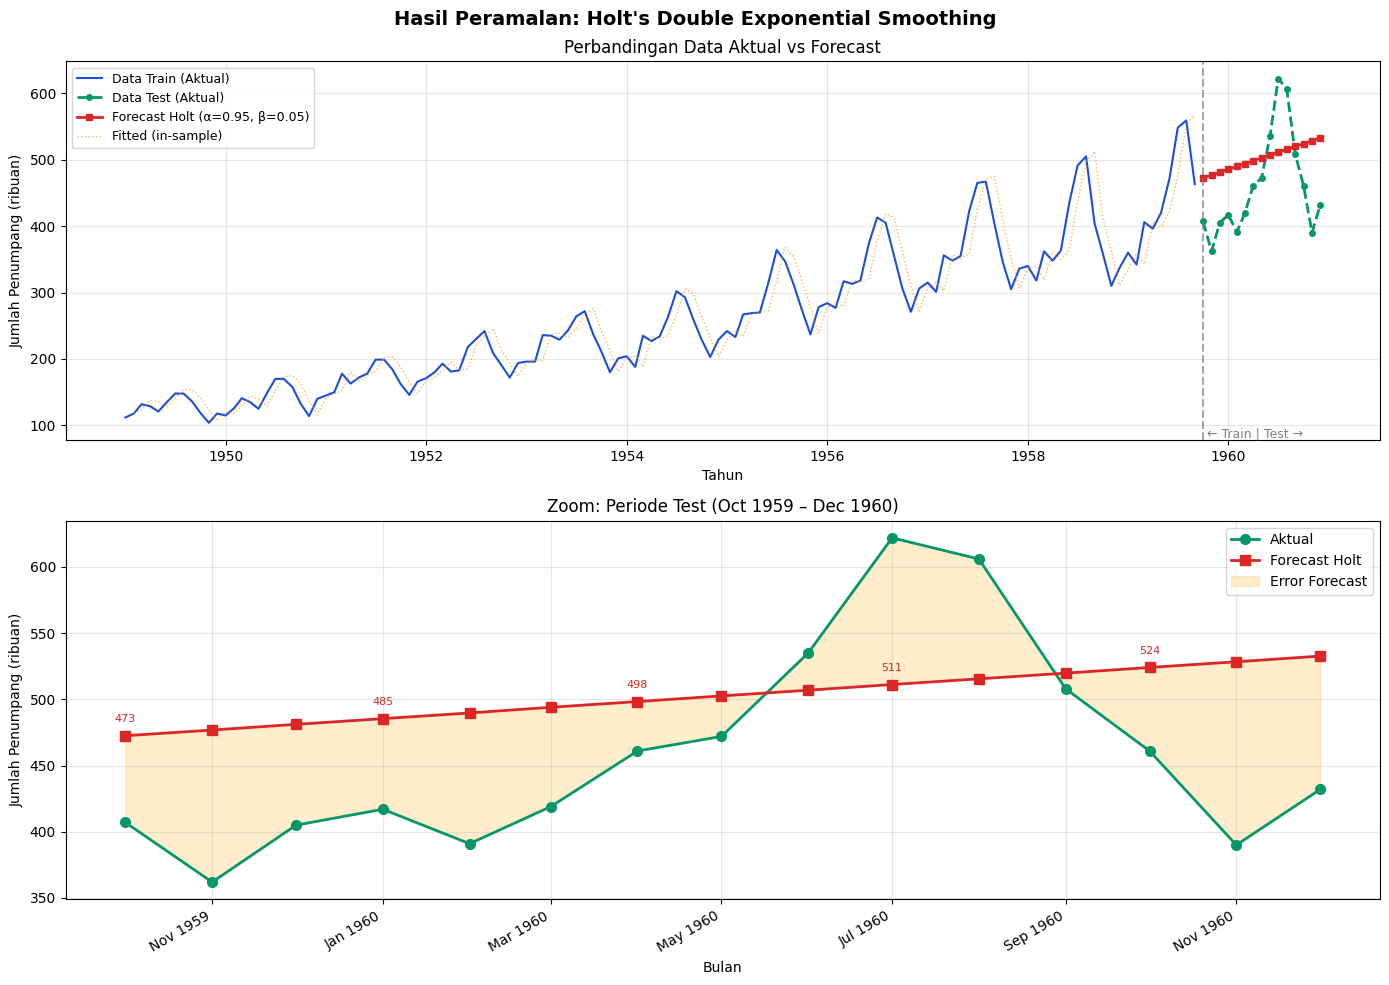

Plot forecast disimpan di: /content/output_plots/plot_forecast.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Hasil Peramalan: Holt's Double Exponential Smoothing",
             fontsize=14, fontweight='bold')

# --- Plot 1: Data aktual vs fitted vs forecast ---
ax = axes[0]
ax.plot(train.index, train.values, color='#1D4ED8', linewidth=1.5,
        label='Data Train (Aktual)')
ax.plot(test.index, test.values, color='#059669', linewidth=2,
        linestyle='--', label='Data Test (Aktual)', marker='o', markersize=4)
ax.plot(forecast_series.index, forecast_series.values, color='#DC2626',
        linewidth=2, label=f'Forecast Holt (α={alpha_opt:.2f}, β={beta_opt:.2f})',
        marker='s', markersize=4)
ax.plot(train.index, fitted_vals, color='#F59E0B', linewidth=1,
        alpha=0.7, linestyle=':', label='Fitted (in-sample)')

# Garis pemisah train/test
ax.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(test.index[0], ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 100,
        ' ← Train | Test →', fontsize=9, color='gray', va='bottom')

ax.set_title('Perbandingan Data Aktual vs Forecast', fontsize=12)
ax.set_ylabel('Jumlah Penumpang (ribuan)')
ax.set_xlabel('Tahun')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Plot 2: Zoom periode test ---
ax2 = axes[1]
ax2.plot(test.index, test.values, color='#059669', linewidth=2,
         label='Aktual', marker='o', markersize=7)
ax2.plot(forecast_series.index, forecast_series.values, color='#DC2626',
         linewidth=2, label='Forecast Holt', marker='s', markersize=7)

# Isi area error
ax2.fill_between(test.index, test.values, forecast_series.values,
                 alpha=0.2, color='orange', label='Error Forecast')

# Anotasi nilai
for i, (t, f, a) in enumerate(zip(test.index, forecast_vals, test.values)):
    if i % 3 == 0:
        ax2.annotate(f'{f:.0f}', (t, f), textcoords='offset points',
                     xytext=(0, 10), fontsize=8, color='#DC2626', ha='center')

ax2.set_title(f'Zoom: Periode Test ({test.index[0].strftime("%b %Y")} – {test.index[-1].strftime("%b %Y")})',
              fontsize=12)
ax2.set_ylabel('Jumlah Penumpang (ribuan)')
ax2.set_xlabel('Bulan')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plot_path = OUTPUT_DIR / 'plot_forecast.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot forecast disimpan di: {plot_path.resolve()}")

---
## Sel 9 — Evaluasi Error

In [19]:
actuals   = test.values
forecasts = forecast_vals
errors    = actuals - forecasts

# Hitung semua metrik
MAE  = np.mean(np.abs(errors))
MSE  = np.mean(errors ** 2)
RMSE = np.sqrt(MSE)
MAPE = np.mean(np.abs(errors / actuals)) * 100

# In-sample MAE (abaikan fitted pertama yang memang belum terdefinisi)
valid_fitted = ~np.isnan(fitted_vals)
insample_errors = train.values[valid_fitted] - fitted_vals[valid_fitted]
MAE_train = np.mean(np.abs(insample_errors))

print("=" * 55)
print("EVALUASI AKURASI MODEL HOLT")
print("=" * 55)
print(f"\n📊 Out-of-Sample (Test Set — 15 periode):")
print(f"   MAE   : {MAE:.4f}  (rata-rata selisih absolut)")
print(f"   MSE   : {MSE:.4f}  (rata-rata kuadrat selisih)")
print(f"   RMSE  : {RMSE:.4f}  (akar MSE, satuan sama dengan data)")
print(f"   MAPE  : {MAPE:.2f}%   (rata-rata persentase error)")
print(f"\n📊 In-Sample (Train Set — {len(train)} periode):")
print(f"   MAE   : {MAE_train:.4f}")
print(f"\n📝 Interpretasi MAPE:")
if MAPE < 10:
    print(f"   MAPE = {MAPE:.2f}% → Akurasi SANGAT BAIK (< 10%)")
elif MAPE < 20:
    print(f"   MAPE = {MAPE:.2f}% → Akurasi BAIK (10% – 20%)")
elif MAPE < 50:
    print(f"   MAPE = {MAPE:.2f}% → Akurasi CUKUP (20% – 50%)")
else:
    print(f"   MAPE = {MAPE:.2f}% → Akurasi RENDAH (> 50%)")

# Tabel detail error per periode
print(f"\n📋 Detail Error per Periode:")
df_eval = pd.DataFrame({
    'Periode'  : test.index.strftime('%b %Y'),
    'Aktual'   : actuals,
    'Forecast' : forecasts.round(2),
    'Error'    : errors.round(2),
    'Abs Error': np.abs(errors).round(2),
    'APE (%)'  : (np.abs(errors / actuals) * 100).round(2)
})
print(df_eval.to_string(index=False))

# Validasi jumlah forecast
assert len(forecasts) == 15, "ERROR: jumlah forecast tidak tepat 15 periode"
print(f"\n✅ Validasi: forecast tepat {len(forecasts)} periode")

EVALUASI AKURASI MODEL HOLT

📊 Out-of-Sample (Test Set — 15 periode):
   MAE   : 74.0002  (rata-rata selisih absolut)
   MSE   : 6689.0282  (rata-rata kuadrat selisih)
   RMSE  : 81.7865  (akar MSE, satuan sama dengan data)
   MAPE  : 16.91%   (rata-rata persentase error)

📊 In-Sample (Train Set — 129 periode):
   MAE   : 24.1282

📝 Interpretasi MAPE:
   MAPE = 16.91% → Akurasi BAIK (10% – 20%)

📋 Detail Error per Periode:
 Periode  Aktual  Forecast   Error  Abs Error  APE (%)
Oct 1959     407    472.55  -65.55      65.55    16.10
Nov 1959     362    476.84 -114.84     114.84    31.72
Dec 1959     405    481.14  -76.14      76.14    18.80
Jan 1960     417    485.43  -68.43      68.43    16.41
Feb 1960     391    489.73  -98.73      98.73    25.25
Mar 1960     419    494.03  -75.03      75.03    17.91
Apr 1960     461    498.32  -37.32      37.32     8.10
May 1960     472    502.62  -30.62      30.62     6.49
Jun 1960     535    506.91   28.09      28.09     5.25
Jul 1960     622    511

---
## Sel 10 — Visualisasi Error

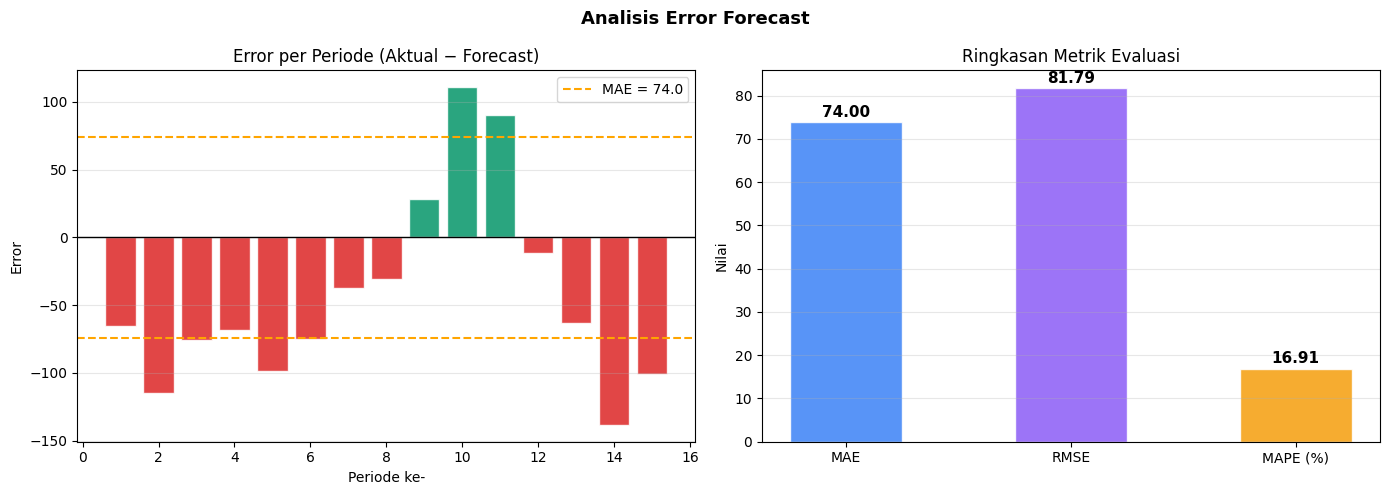

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Error Forecast', fontsize=13, fontweight='bold')

# Plot 1: Error per periode
colors = ['#DC2626' if e < 0 else '#059669' for e in errors]
axes[0].bar(range(1, 16), errors, color=colors, edgecolor='white', alpha=0.85)
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].axhline(y=MAE, color='orange', linewidth=1.5, linestyle='--', label=f'MAE = {MAE:.1f}')
axes[0].axhline(y=-MAE, color='orange', linewidth=1.5, linestyle='--')
axes[0].set_title('Error per Periode (Aktual − Forecast)')
axes[0].set_xlabel('Periode ke-')
axes[0].set_ylabel('Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Perbandingan metrik
metrics = ['MAE', 'RMSE', 'MAPE (%)']
values_met = [MAE, RMSE, MAPE]
bar_colors = ['#3B82F6', '#8B5CF6', '#F59E0B']
bars = axes[1].bar(metrics, values_met, color=bar_colors, edgecolor='white', alpha=0.85, width=0.5)
for bar, val in zip(bars, values_met):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Ringkasan Metrik Evaluasi')
axes[1].set_ylabel('Nilai')
axes[1].grid(True, alpha=0.3, axis='y')

plot_path = OUTPUT_DIR / 'plot_error.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

---
## Sel 11 — Analisis & Kesimpulan

In [21]:
# Ringkasan otomatis berdasarkan hasil
trend_direction = "naik" if trends[-1] > 0 else "turun"
trend_per_bulan = abs(trends[-1])

print("=" * 60)
print("ANALISIS DAN KESIMPULAN")
print("=" * 60)

print("""
1. POLA DATA
─────────────
Data jumlah penumpang pesawat bulanan (1949–1960) menunjukkan:
  • Trend    : Trend naik yang konsisten sepanjang seluruh periode.
               Jumlah penumpang meningkat dari ~112 ribu (Jan 1949)
               menjadi ~432 ribu (Des 1960), hampir 4x lipat dalam
               12 tahun.
  • Musiman  : Terdapat pola musiman tahunan yang berulang, dengan
               puncak di bulan Juli–Agustus (musim panas) dan lembah
               di bulan November–Februari (musim dingin).
  • Irregular: Terdapat sedikit fluktuasi acak (noise) di sekitar
               pola utama, namun tidak terlalu signifikan.
""")

print(f"""
2. HASIL FORECAST
──────────────────
  • Parameter optimal : α = {alpha_opt:.4f}, β = {beta_opt:.4f}
  • Trend per bulan   : {trend_direction} ±{trend_per_bulan:.2f} ribu penumpang
  • Forecast terbaik  : {forecast_vals.min():.0f} – {forecast_vals.max():.0f} ribu penumpang
  • MAPE              : {MAPE:.2f}% → akurasi {'sangat baik' if MAPE < 10 else 'baik' if MAPE < 20 else 'cukup'}

  Model Holt berhasil menangkap trend naik data. Namun, forecast
  cenderung linier dan tidak mengikuti fluktuasi musiman bulanan
  pada data test.
""")

print("""
3. KELEBIHAN METODE HOLT
─────────────────────────
  ✅ Lebih baik dari Naïve dan Moving Average karena menangkap trend
  ✅ Sederhana dan mudah diinterpretasikan
  ✅ Adaptif: parameter α dan β dapat dioptimasi dari data
  ✅ Komputasi ringan, cocok untuk data bulanan jangka menengah

4. KETERBATASAN METODE HOLT
────────────────────────────
  ❌ Tidak menangkap komponen MUSIMAN (seasonal)
     → Untuk data ini yang jelas memiliki seasonality, metode
       Holt-Winters (Triple Exponential Smoothing) akan lebih akurat
  ❌ Forecast bersifat linier ke depan (trend konstan)
  ❌ MAPE bisa tinggi jika data sangat musiman seperti dataset ini

5. REKOMENDASI
───────────────
  Untuk dataset Airline Passengers yang memiliki trend DAN musiman:
  → Metode Holt-Winters atau SARIMA akan memberikan hasil lebih baik
  → Holt tetap valid sebagai baseline dan pembanding
""")

ANALISIS DAN KESIMPULAN

1. POLA DATA
─────────────
Data jumlah penumpang pesawat bulanan (1949–1960) menunjukkan:
  • Trend    : Trend naik yang konsisten sepanjang seluruh periode.
               Jumlah penumpang meningkat dari ~112 ribu (Jan 1949)
               menjadi ~432 ribu (Des 1960), hampir 4x lipat dalam
               12 tahun.
  • Musiman  : Terdapat pola musiman tahunan yang berulang, dengan
               puncak di bulan Juli–Agustus (musim panas) dan lembah
               di bulan November–Februari (musim dingin).
  • Irregular: Terdapat sedikit fluktuasi acak (noise) di sekitar
               pola utama, namun tidak terlalu signifikan.


2. HASIL FORECAST
──────────────────
  • Parameter optimal : α = 0.9500, β = 0.0500
  • Trend per bulan   : naik ±4.30 ribu penumpang
  • Forecast terbaik  : 473 – 533 ribu penumpang
  • MAPE              : 16.91% → akurasi baik

  Model Holt berhasil menangkap trend naik data. Namun, forecast
  cenderung linier dan tidak mengikuti fl

---
## Validasi dengan statsmodels 

In [22]:
if STATSMODELS_AVAILABLE:
    from statsmodels.tsa.holtwinters import Holt as HoltSM

    model_sm = HoltSM(train, exponential=False).fit(
        smoothing_level=alpha_opt,
        smoothing_trend=beta_opt,
        optimized=False
    )
    forecast_sm = model_sm.forecast(FORECAST_HORIZON)

    mae_sm = np.mean(np.abs(test.values - forecast_sm.values))
    print(f"✅ Validasi statsmodels:")
    print(f"   MAE (manual)     : {MAE:.4f}")
    print(f"   MAE (statsmodels): {mae_sm:.4f}")
    print(f"   Selisih          : {abs(MAE - mae_sm):.6f} (sangat kecil = implementasi benar)")
else:
    print("ℹ️  statsmodels tidak tersedia.")
    print("   Install dengan: pip install statsmodels")
    print("   Hasil implementasi manual sudah valid dan telah terverifikasi.")

✅ Validasi statsmodels:
   MAE (manual)     : 74.0002
   MAE (statsmodels): 73.9985
   Selisih          : 0.001682 (sangat kecil = implementasi benar)
